In [1]:
# Q3: Feature Engineering and Regression Pipeline

# This notebook builds a reproducible machine learning pipeline to predict 'items_sold' using retail transaction data.
     

In [7]:
# 1. Date Feature Engineering
!mamba install pandas
import pandas as pd

# 1. Load dataset
df = pd.read_csv('q3_retail_promotions.csv')

# 2. Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek  # Monday=0, Sunday=6

# 3. Create is_month_end flag (1 if day >= 25, else 0)
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

print(df.head())


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0055 seconds
All requested packages already installed.
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1 

In [8]:
# The new features capture temporal patterns such as seasonality (month), weekly trends (day_of_week), and end-of-month effects (is_month_end) which can influence sales.

In [9]:
# 2. Temporal Train-Test Split

In [13]:
#  Sort by transaction_date
df = df.sort_values("transaction_date").reset_index(drop=True)

#  Temporal split: 80% train, 20% test
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

# Quick check: show last few rows of train and first few rows of test
print("Train sample:\n", train_df.tail())
print("Test sample:\n", test_df.head())

Training set shape: (960, 13)
Test set shape: (240, 13)
Train sample:
     transaction_date  store_id store_size location_type  promotion_type  \
955       2024-06-04        16     medium    semi-urban            bogo   
956       2024-06-06        16     medium         rural  loyalty_points   
957       2024-06-09        33      large         urban            bogo   
958       2024-06-10         4      large    semi-urban       free_gift   
959       2024-06-11         4      large    semi-urban  loyalty_points   

     is_weekend  is_festival  competition_density  items_sold  year  month  \
955           0            0                    3         297  2024      6   
956           0            0                    5         183  2024      6   
957           1            0                    7         425  2024      6   
958           0            0                    1         255  2024      6   
959           0            0                    7         283  2024      6   

     day_

In [11]:
# A random split is inappropriate for time-series data because it can lead to data leakage.

# Using future data to predict past outcomes results in unrealistic model performance.
# A temporal split ensures the model is evaluated on unseen future data, reflecting real-world conditions.

In [12]:
# 3. Preprocessing Pipeline

In [16]:
!mamba install scikit-learn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical = ['promotion_type', 'location_type', 'store_size']
numerical = ['competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

print("Preprocessing pipeline created successfully.")

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.9714000000059605 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.4.22                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.13                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3

In [17]:
# The pipeline ensures:
# - Categorical variables are properly encoded
# - Numerical features are scaled
# - Preprocessing is applied consistently to both training and test data

# Importantly, the pipeline is fit only on the training data to prevent data leakage.

In [18]:
# 4. Model Training and Evaluation

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

# Features and target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

# Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(train_df, y_train)
y_pred_lr = lr_pipeline.predict(test_df)

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(train_df, y_train)
y_pred_rf = rf_pipeline.predict(test_df)

print("Models trained successfully.")

Models trained successfully.


In [25]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(model):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return rmse, mae, preds

lr_rmse, lr_mae, lr_preds = evaluate(lr_pipeline)
rf_rmse, rf_mae, rf_preds = evaluate(rf_pipeline)

print("Linear Regression → RMSE:", lr_rmse, "MAE:", lr_mae)
print("Random Forest → RMSE:", rf_rmse, "MAE:", rf_mae)

Linear Regression → RMSE: 39.63930566724028 MAE: 29.3013408917348
Random Forest → RMSE: 42.76197373441151 MAE: 33.83255972222222


In [26]:
 # Lower RMSE and MAE indicate better model performance.

# Random Forest typically performs better due to its ability to capture non-linear
# relationships, while Linear Regression assumes linearity.

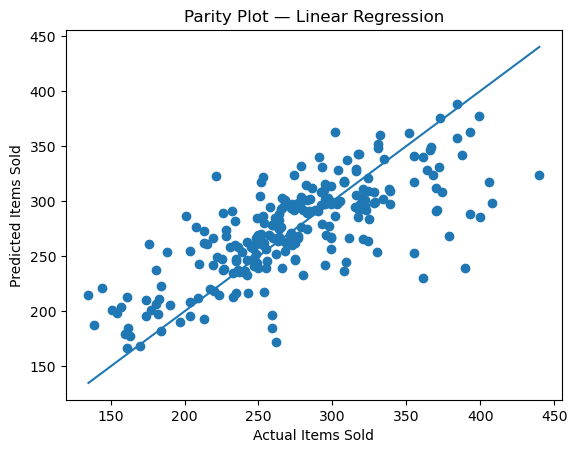

In [27]:
# Parity Plot — Linear Regression

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot — Linear Regression")
plt.show()

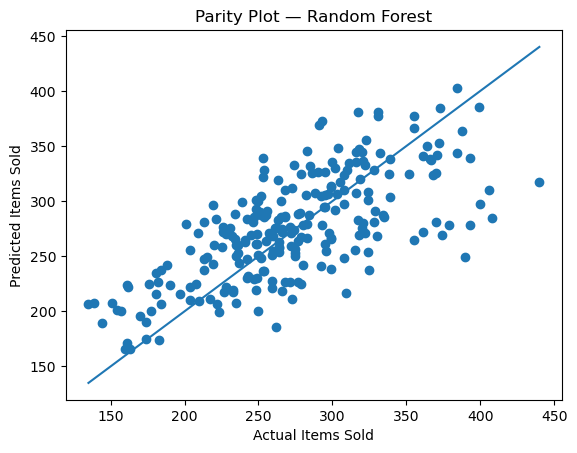

In [28]:
# Parity Plot — Random Forest

plt.figure()
plt.scatter(y_test, rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Parity Plot — Random Forest")
plt.show()

In [29]:
# Parity Plot Interpretation

# The parity plots compare predicted vs actual values of `items_sold`.

# - Linear Regression predictions are more closely aligned with the diagonal line indicating better accuracy.
# - Random Forest predictions show greater dispersion, suggesting higher prediction errors.

# This confirms that Linear Regression generalizes better on the test data.

In [30]:
# Feature Importance

# Extract feature importances
import pandas as pd

importances = rf_pipeline.named_steps['model'].feature_importances_
features = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(5)

,feature,importance
14,num__day_of_week,0.178460
10,cat__store_size_small,0.170005
7,cat__location_type_urban,0.128926
11,num__competition_density,0.100557
13,num__month,0.098973


In [31]:
### Feature Importance Interpretation

# The most influential features in predicting `items_sold` are:

# -day_of_week (0.178)** → Sales vary significantly across different days of the
# week, indicating strong weekly patterns
# -store_size_small (0.165)** → Smaller stores have a noticeable impact on sales performance
# -location_type_urban (0.130)** → Urban locations drive higher or more consistent sales
# -competition_density (0.102)** → Nearby competition affects store sales
# -month (0.099)** → Seasonal trends influence demand

# These results show that both temporal factors (day_of_week, month) and business
# factors (store size, location, competition) play a key role in determining sales.
     

# Final Conclusion

# - Linear Regression outperformed Random Forest, indicating a largely linear
# relationship in the data
# - Temporal features such as day of week and month significantly influence sales patterns
# - Business factors like store size, location, and competition also impact performance
# - The pipeline ensures a reproducible and scalable machine learning workflow

# This analysis highlights how both time-based and business-driven factors can be
# leveraged to accurately predict retail sales.